### Initialization

In [1]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "0"

In [2]:
import math
import random
from time import perf_counter

In [3]:
import pandas as pd
import numpy as np

In [4]:
from gensim.models import Word2Vec

In [5]:
from sklearn.metrics import f1_score

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Sampler
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
from torch.amp import autocast, GradScaler

torch._inductor.config.triton.cudagraph_skip_dynamic_graphs=True
torch.backends.fp32_precision = "tf32"
torch.backends.cudnn.fp32_precision = "tf32"
torch.backends.cudnn.rnn.fp32_precision = "tf32"

In [7]:
assert torch.cuda.is_available()
device = torch.device("cuda")
print(f"Device: {device}")

Device: cuda


In [8]:
from nn_lstm_preprocessing import get_preprocessed_data
from nn_model_classes import WordRNN, ArticleDataset, MySampler

### Prepare dataset for neural network

In [9]:
embedding_model = Word2Vec.load("../models/embedding_model.model")

In [10]:
data = get_preprocessed_data(embedding_model)
data.head()

Processed chunks: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 

,content,type
0,"[tensor(591), tensor(13), tensor(195), tensor(...",1
1,"[tensor(382), tensor(262), tensor(203), tensor...",0
2,"[tensor(209), tensor(34015), tensor(2), tensor...",0
3,"[tensor(5493), tensor(32553), tensor(151), ten...",1
4,"[tensor(52), tensor(2), tensor(1363), tensor(2...",0


In [11]:
# Shuffle dataset randomly
data = data.sample(frac=1, random_state=0)
data.reset_index(inplace=True, drop=True)

In [12]:
# Group articles into buckets using the amount of tokens in each article
buckets = [0, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768]
data["bucket"] = pd.cut(data["content"].apply(lambda x: x.shape[0]), bins=buckets, labels=buckets[1:])

In [13]:
# Check amount of articles in each bucket
data.groupby("bucket", observed=True).size()

bucket
8          8461
16        44657
32        68083
64        67885
128      134678
256      169273
512      226486
1024     140931
2048      34300
4096       7074
8192       1549
16384       294
32768         7
dtype: int64

In [14]:
split_index1 = int(len(data)*0.8)
split_index2 = int(len(data)*0.9)

train_set = data.iloc[:split_index1]
val_set = data.iloc[split_index1:split_index2]
test_set = data.iloc[split_index2:]

#### Prepare dataloaders for neural network

In [15]:
bucket_to_batch_size = {
    8: 512, 
    16: 512, 
    32: 512, 
    64: 512, 
    128: 512, 
    256: 512, 
    512: 256, 
    1024: 128, 
    2048: 64, 
    4096: 32, 
    8192: 16, 
    16384: 8, 
    32768: 4,
}

In [16]:
train_sampler = MySampler(train_set.groupby("bucket", observed=True), bucket_to_batch_size)

train_dataloader = DataLoader(
    ArticleDataset(train_set), 
    batch_size=1,
    sampler=train_sampler,
    num_workers=4,
    collate_fn=None, 
    pin_memory=True,
    persistent_workers=True,
)

In [17]:
val_sampler = MySampler(val_set.groupby("bucket", observed=True), bucket_to_batch_size)

val_dataloader = DataLoader(
    ArticleDataset(val_set), 
    batch_size=1,
    sampler=val_sampler,
    num_workers=4,
    collate_fn=None, 
    pin_memory=True,
    persistent_workers=True,
)

In [18]:
test_sampler = MySampler(test_set.groupby("bucket", observed=True), bucket_to_batch_size)

test_dataloader = DataLoader(
    ArticleDataset(test_set), 
    batch_size=1,
    sampler=test_sampler,
    num_workers=4,
    collate_fn=None, 
    pin_memory=True,
    persistent_workers=True,
)

### Neural network model

In [19]:
model = WordRNN(embedding_model, 128, 256)
# Embedding dim: 128
# Hidden dim: 256

model = model.to("cuda")
model = torch.compile(model, mode="max-autotune-no-cudagraphs")
model

OptimizedModule(
  (_orig_mod): WordRNN(
    (word_embeddings): Embedding(385220, 128)
    (lstm): LSTM(128, 256, batch_first=True, bidirectional=True)
    (fc): Linear(in_features=256, out_features=1, bias=True)
  )
)

### Training the model

In [20]:
scaler = GradScaler()
criterion = nn.BCEWithLogitsLoss(reduction="sum")
optimizer = optim.Adam(model.parameters(), lr=0.0005)

In [21]:
# Trains model with a single batch of news articles 
def train_one_batch(model, batch_articles, article_lengths, batch_labels):
    batch_articles = batch_articles.squeeze(0)
    article_lengths = article_lengths.squeeze(0)
    batch_labels = batch_labels.squeeze(0)

    optimizer.zero_grad(set_to_none=True)

    batch_articles = batch_articles.to(device, non_blocking=True)
    batch_labels = batch_labels.to(device, non_blocking=True)

    with autocast(device_type="cuda"):
        outputs = model(batch_articles, article_lengths).view(batch_labels.size(0))
        batch_loss = criterion(outputs, batch_labels)
    
    scaler.scale(batch_loss).backward()
        
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    scaler.step(optimizer)
        
    scaler.update()

    return batch_loss.item()

In [22]:
# Returns the loss from evaluaring a single batch of articles
def evaluate_one_batch(model, batch_articles, article_lengths, batch_labels):
    batch_articles = batch_articles.squeeze(0)
    article_lengths = article_lengths.squeeze(0)
    batch_labels = batch_labels.squeeze(0)
    
    batch_articles = batch_articles.to(device, non_blocking=True)
    batch_labels = batch_labels.to(device, non_blocking=True)
    
    outputs = model(batch_articles, article_lengths).view(batch_labels.size(0))
    batch_loss = criterion(outputs, batch_labels)

    return batch_loss.item()

In [23]:
epoch_training_losses = []
epoch_validation_losses = []

best_loss = np.inf
last_val_avg_loss = np.inf
best_model_state = None
epochs_since_last_improvement = 0

#### Training loop

In [24]:
start_time = perf_counter()
epoch_start_time = perf_counter()
for epoch in range(0, 20):
    # Train one epoch
    model.train()
    epoch_training_loss = 0.0
    epoch_training_samples = 0
    for index, (batch_articles, article_lengths, batch_labels) in enumerate(train_dataloader):
        batch_loss = train_one_batch(model, batch_articles, article_lengths, batch_labels)
        epoch_training_loss += batch_loss
        epoch_training_samples += batch_articles.shape[0]
            
    avg_epoch_training_loss = epoch_training_loss / epoch_training_samples

    # Evaluate model using validation set for early stopping to prevent overfitting
    model.eval()
    epoch_val_loss = 0.0
    epoch_val_samples = 0
    with torch.no_grad():
        for index, (batch_articles, article_lengths, batch_labels) in enumerate(val_dataloader):
            batch_loss = evaluate_one_batch(model, batch_articles, article_lengths, batch_labels)            
            epoch_val_loss += batch_loss
            epoch_val_samples += batch_articles.shape[0]

    avg_epoch_val_loss = epoch_val_loss / epoch_val_samples

    
    epoch_end_time = perf_counter()
    print(f"\nEpoch {epoch}")
    print(f"Avg training loss: {avg_epoch_training_loss:.3f}. Avg eval loss: {avg_epoch_val_loss:.3f}.")
    print(f"Eval loss changed by {avg_epoch_val_loss - last_val_avg_loss:.3f}. Improved by {avg_epoch_val_loss - best_loss:.3f} compared to best.")
    print(f"Elapsed time: {epoch_end_time - epoch_start_time:.3f} seconds.")

    if avg_epoch_val_loss < best_loss:
        improvement = best_loss - avg_epoch_val_loss
        best_loss = avg_epoch_val_loss
        best_model_state = model.state_dict()

        if improvement > 0.001: # Dont treat noise as an improvement
            epochs_since_last_improvement = 0
        else:
            epochs_since_last_improvement += 1
    else:
        epochs_since_last_improvement += 1
        
    if epochs_since_last_improvement == 4:
        print(f"Stopping early at epoch {epoch}. Total time elapsed: {perf_counter() - start_time:.3f} seconds.")
        break
            
    last_val_avg_loss = avg_epoch_val_loss
    epoch_training_losses.append(avg_epoch_training_loss)
    epoch_validation_losses.append(avg_epoch_val_loss)
    epoch_start_time = epoch_end_time


Epoch 0
Avg training loss: 84.640. Avg eval loss: 65.085.
Eval loss changed by -inf. Improved by -inf compared to best.
Elapsed time: 279.837 seconds.

Epoch 1
Avg training loss: 59.511. Avg eval loss: 52.432.
Eval loss changed by -12.652. Improved by -12.652 compared to best.
Elapsed time: 276.869 seconds.

Epoch 2
Avg training loss: 46.499. Avg eval loss: 41.512.
Eval loss changed by -10.920. Improved by -10.920 compared to best.
Elapsed time: 276.242 seconds.

Epoch 3
Avg training loss: 39.099. Avg eval loss: 39.030.
Eval loss changed by -2.482. Improved by -2.482 compared to best.
Elapsed time: 276.854 seconds.

Epoch 4
Avg training loss: 35.149. Avg eval loss: 34.511.
Eval loss changed by -4.519. Improved by -4.519 compared to best.
Elapsed time: 276.712 seconds.

Epoch 5
Avg training loss: 32.139. Avg eval loss: 32.533.
Eval loss changed by -1.978. Improved by -1.978 compared to best.
Elapsed time: 276.841 seconds.

Epoch 6
Avg training loss: 29.609. Avg eval loss: 30.942.
Eval 

In [25]:
# Save model
torch.save(best_model_state, "../models/nn_model.pth")

In [30]:
# Save loss per epoch for analysis
pd.DataFrame(
    {"train_loss": epoch_training_losses, 
     "val_loss": epoch_validation_losses}
).to_csv("../data/nn_model_loss.csv")

### Testing the model on the FakeNewsCorpus

In [31]:
# Load model
model.load_state_dict(torch.load("../models/nn_model.pth"))

<All keys matched successfully>

In [32]:
torch.cuda.empty_cache()

In [33]:
model.eval()
predictions = []
true_labels = []

with torch.no_grad():
    for index, (batch_articles, article_lengths, batch_labels) in enumerate(test_dataloader):
        batch_articles = batch_articles.squeeze(0)
        article_lengths = article_lengths.squeeze(0)
        batch_labels = batch_labels.squeeze(0)

        batch_articles = batch_articles.to(device, non_blocking=True)

        output = model(batch_articles, article_lengths)

        probs = torch.sigmoid(output)
        prediction = (probs > 0.5).long().cpu()
        
        predictions.append(prediction)
        true_labels.append(batch_labels)

In [34]:
test_f1score = f1_score(torch.cat(true_labels), torch.cat(predictions), pos_label=1)
test_f1score

0.945928265283104

### Analyzing results

In [52]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

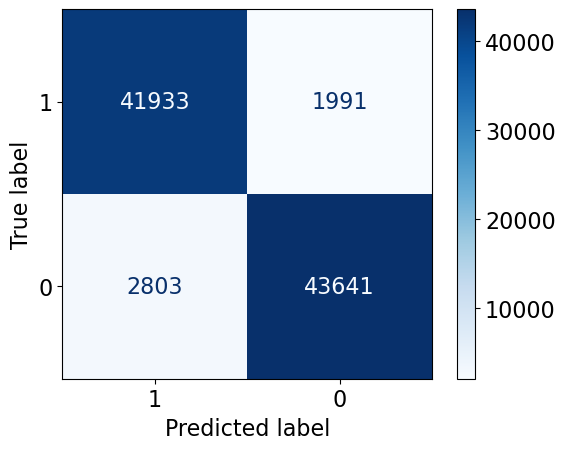

In [60]:
fig, ax = plt.subplots()
plt.rcParams.update({'font.size': 16})
ConfusionMatrixDisplay.from_predictions(
    torch.cat(true_labels), 
    torch.cat(predictions), 
    labels=[1, 0],
    display_labels=[1, 0],
    cmap="Blues",
    ax=ax
)

In [65]:
loss_data = pd.read_csv("../data/nn_model_loss.csv", index_col=0)
loss_data.rename(columns={"train_loss": "Training loss", "val_loss": "Validation loss"}, inplace=True)

<Axes: xlabel='Epoch', ylabel='Binary cross entropy loss'>

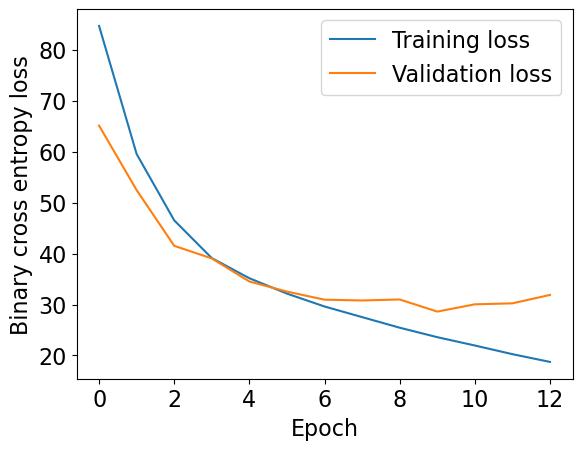

In [69]:
loss_data.plot(xlabel="Epoch", ylabel="Binary cross entropy loss")